<center>
    
# Data Science Project: Loan Approval & Risk Prediction System

</center>

---

## Project Overview
When people apply for a loan, banks need to make a smart decision: **Should we approve the loan or reject it?** 
* If the bank approves a loan for someone who cannot pay it back, the bank loses money.
* If the bank rejects a good applicant, the bank loses a customer.

**Our Goal:** Use data from 52,000 previous applicants to train a model that can predict applicant should be approved or rejected.


---

## Step 1: Business Understanding
Before writing any code, we need to know what problem we are solving for the business.
* **The Core Problem:** Avoid lending money to high-risk applicants.
* **Goal:** Optimize loan approvals (`Loan_Approval_Status`) and minimize credit risk (`Default_Risk`).
* **The Smart Focus (Recall):** In banking, missing a bad applicant is much more expensive than accidentally turning away a good one. We want our model to catch high-risk borrowers and protect capital.
* **Data Scale:** 52,000 applicants across 27 predictive features.


In [23]:
# ==========================================
# 1. UNIFIED SYSTEM IMPORTS & CONFIGURATION
# ==========================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization & Styling
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Machine Learning Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

print("All libraries successfully imported!")

All libraries successfully imported!


---

## Step 2: Data Collection
We are working with a dataset containing **52,000 applicants** and **27 columns of information**. This data includes:
1. **Demographics:** Age, Gender, Education, Marital Status.
2. **Financials:** Annual Income, Monthly Expenses, Existing Loans, Outstanding Debt.
3. **Credit History:** Credit Score, Bank Account History.


In [3]:
# ==========================================
# 2. DATA INGESTION & QUALITY CHECK
# ==========================================

# Load the dataset (replace with your file path if different)
df = pd.read_csv(r"C:\Users\AKSHAY KUMAR D R\DataScience\Project\Loan Dataset.csv")

# Drop unique identifier to prevent data leakage
df = df.drop(columns=['Applicant_ID'], errors='ignore')

# Display structure and check for missing values
print(f"Dataset Shape: {df.shape}\n")
print("--- Missing Values Per Column ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0] if missing_data.sum() > 0 else "No missing values found!")

# Preview the first 3 rows cleanly
df.head(3)


Dataset Shape: (52000, 26)

--- Missing Values Per Column ---
No missing values found!


,Gender,Age,Marital_Status,Dependents,Education,Employment_Status,Occupation_Type,Residential_Status,City/Town,Annual_Income,...,Loan_Amount_Requested,Loan_Term,Loan_Purpose,Interest_Rate,Loan_Type,Co-Applicant,Bank_Account_History,Transaction_Frequency,Default_Risk,Loan_Approval_Status
0,Female,25,Married,2,Graduate,Employed,Business,Own,Urban,139901,...,24535,209,Home,4.27,Secured,Yes,8,20,0.81,1
1,Male,36,Married,2,High School,Employed,Business,Own,Suburban,21162,...,8288,33,Home,14.78,Unsecured,Yes,9,9,0.17,0
2,Male,43,Single,0,Postgraduate,Self-Employed,Freelancer,Own,Urban,27815,...,10308,159,Vehicle,12.33,Secured,Yes,7,27,0.25,0


---

## Step 3: Data Cleaning & Inspection
Raw data is often messy, full of duplicates, or missing pieces. In this step, we checked the quality of our data:
* **The Good News:** Our dataset had **0 duplicate rows** and **0 missing values**!
* **ID Removal:** We dropped the `Applicant_ID` column. Why? Because an ID number is just a random label (like a serial number) and doesn't tell us anything about whether a person is good at paying back loans. Keeping it would only confuse our model.


In [4]:
# ==========================================
# 3. DATA CLEANING & INITIAL INSPECTION
# ==========================================

# 3.1 Load Dataset
file_path = r"C:\Users\AKSHAY KUMAR D R\DataScience\Project\Loan Dataset.csv"
df = pd.read_csv(file_path)
print("Initial Dataset Shape: ", df.shape)
print("-" * 60)

# 3.2 Missing Values Summary
print("Missing Values Detected:")
missing_summary = df.isnull().sum()
print(missing_summary)
print("-" * 60)

# 3.3 Integrity Checks (Duplicates & ID Removal)
duplicate_count = df.duplicated().sum()
print(f"Duplicate Rows Found: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()

if 'Applicant_ID' in df.columns:
    df = df.drop(columns=['Applicant_ID'])
    print("Removed 'Applicant_ID' column.")
print("-" * 60)

# 3.4 Feature Type Breakdown
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numerical Columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical Columns ({len(categorical_cols)}): {categorical_cols}")
print("-" * 60)

# 3.5 Categorical Value Distribution (Brief Overview)
print("Unique Values in Categorical Columns:")
for col in categorical_cols:
    print(f" -> {col}: {df[col].nunique()} unique values")
print("-" * 60)

# Display a clean preview of data metrics
df.describe().T


Initial Dataset Shape:  (52000, 27)
------------------------------------------------------------
Missing Values Detected:
Applicant_ID                  0
Gender                        0
Age                           0
Marital_Status                0
Dependents                    0
Education                     0
Employment_Status             0
Occupation_Type               0
Residential_Status            0
City/Town                     0
Annual_Income                 0
Monthly_Expenses              0
Credit_Score                  0
Existing_Loans                0
Total_Existing_Loan_Amount    0
Outstanding_Debt              0
Loan_History                  0
Loan_Amount_Requested         0
Loan_Term                     0
Loan_Purpose                  0
Interest_Rate                 0
Loan_Type                     0
Co-Applicant                  0
Bank_Account_History          0
Transaction_Frequency         0
Default_Risk                  0
Loan_Approval_Status          0
dtype: int64
-

,count,mean,std,min,25%,50%,75%,max
Age,52000.0,38.898385,10.553928,18.0,31.00,38.00,45.00,69.0
Dependents,52000.0,1.498000,1.118077,0.0,0.00,1.00,2.00,3.0
Annual_Income,52000.0,83588.474404,35720.851522,20009.0,55564.00,78839.00,114226.00,149998.0
Monthly_Expenses,52000.0,2748.064885,1295.678763,500.0,1636.00,2739.00,3866.00,4999.0
Credit_Score,52000.0,678.089019,159.990367,300.0,553.00,742.00,796.00,849.0
Existing_Loans,52000.0,0.997865,0.815586,0.0,0.00,1.00,2.00,2.0
Total_Existing_Loan_Amount,52000.0,24939.087962,14407.886552,0.0,12498.00,24964.00,37399.50,49999.0
Outstanding_Debt,52000.0,14984.864923,8663.404305,0.0,7511.75,14984.50,22432.25,29998.0
Loan_History,52000.0,0.198596,0.398947,0.0,0.00,0.00,0.00,1.0
Loan_Amount_Requested,52000.0,21102.765481,8224.940906,5000.0,16941.75,21039.00,25809.00,44848.0


---

## Step 4: Exploratory Data Analysis (EDA)
This is where we look at charts to spot interesting patterns. We discovered:
* **Target Balance:** Roughly **64%** of loans in our history were Approved, and **36%** were Rejected. This is a healthy, balanced mix for our model to learn from.
* **Key Drivers:** We visualized how columns like `Credit_Score` play a massive role in whether someone gets approved.


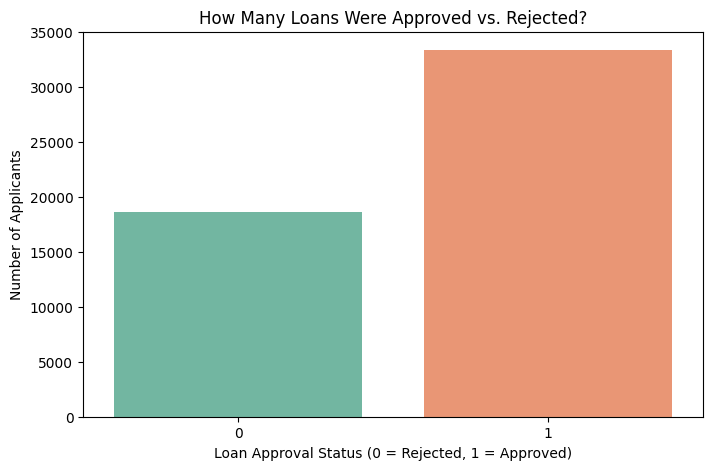

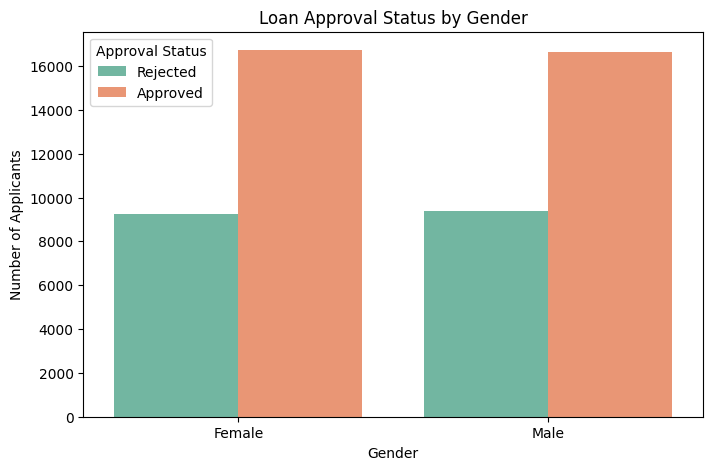

In [5]:
# ==========================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

# Plot 1: Target Class Balance
plt.figure(figsize=(8, 5))
sns.countplot(x='Loan_Approval_Status', data=df, hue='Loan_Approval_Status', palette='Set2', legend=False)
plt.title('How Many Loans Were Approved vs. Rejected?')
plt.xlabel('Loan Approval Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Number of Applicants')
plt.show()

# Plot 2: Approval Rates by Gender
plt.figure(figsize=(8, 5))
sns.countplot(x='Gender', hue='Loan_Approval_Status', data=df, palette='Set2')
plt.title('Loan Approval Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Applicants')
plt.legend(title='Approval Status', labels=['Rejected', 'Approved'])
plt.show()


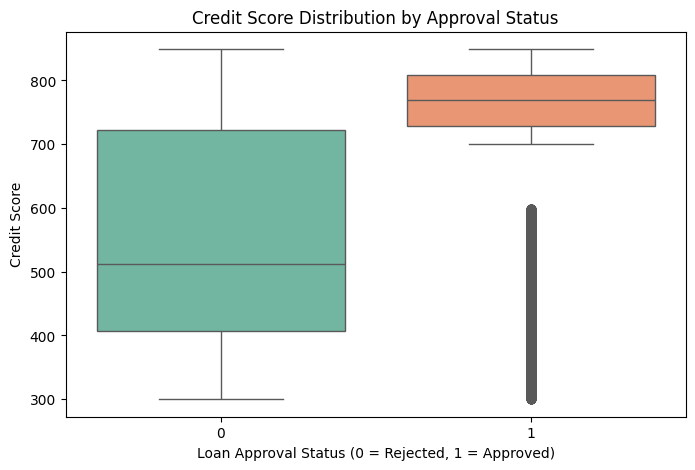

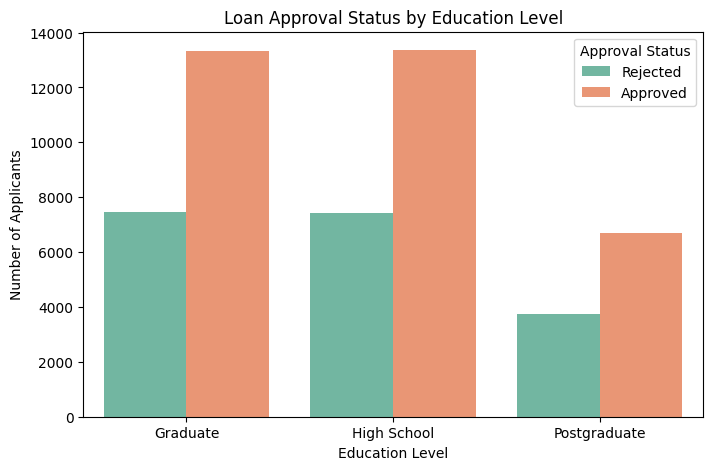

In [6]:
# Plot 3: Credit Score vs. Loan Approval
plt.figure(figsize=(8, 5))
sns.boxplot(x='Loan_Approval_Status', y='Credit_Score', data=df, hue='Loan_Approval_Status', palette='Set2', legend=False)
plt.title('Credit Score Distribution by Approval Status')
plt.xlabel('Loan Approval Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Credit Score')
plt.show()

# Plot 4: Education Level vs. Loan Approval
plt.figure(figsize=(8, 5))
sns.countplot(x='Education', hue='Loan_Approval_Status', data=df, palette='Set2')
plt.title('Loan Approval Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Applicants')
plt.legend(title='Approval Status', labels=['Rejected', 'Approved'])
plt.show()


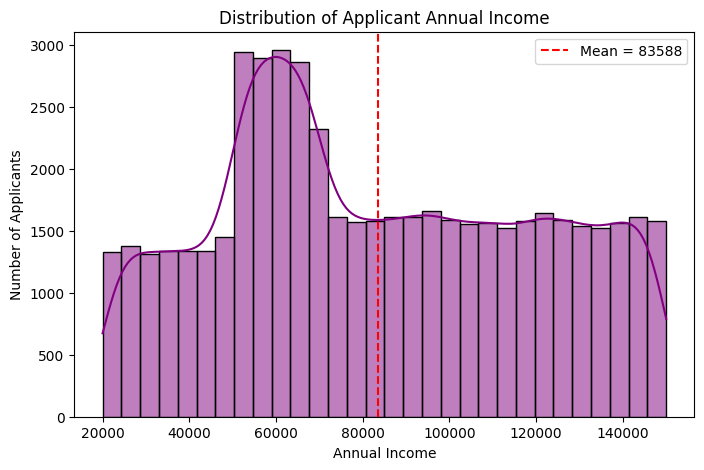

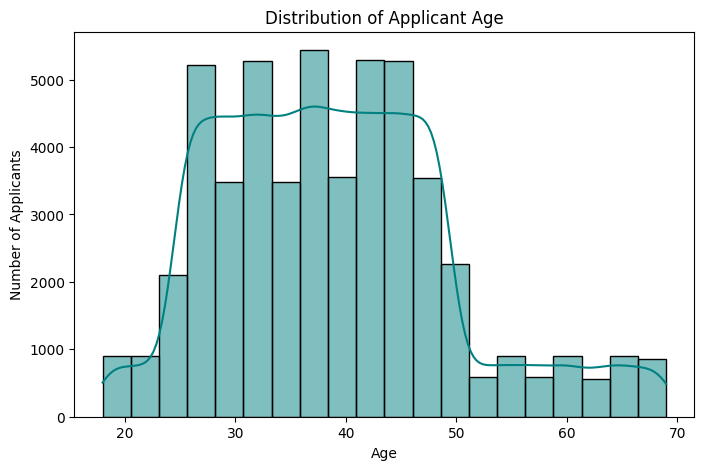

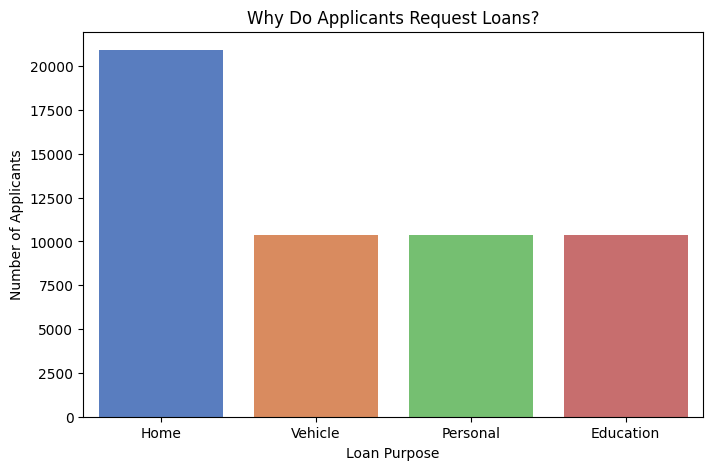

In [7]:
# Plot 5: Clean Annual Income Distribution with Mean Line
plt.figure(figsize=(8, 5))
sns.histplot(df['Annual_Income'], bins=30, kde=True, color='purple')
mean_income = df['Annual_Income'].mean()
plt.axvline(mean_income, color='red', linestyle='--', label=f'Mean = {mean_income:.0f}')
plt.title('Distribution of Applicant Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Number of Applicants')
plt.legend()
plt.show()

# Plot 6: Age Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='teal')
plt.title('Distribution of Applicant Age')
plt.xlabel('Age')
plt.ylabel('Number of Applicants')
plt.show()

# Plot 7: Loan Purpose Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Loan_Purpose', data=df, hue='Loan_Purpose', palette='muted', legend=False)
plt.title('Why Do Applicants Request Loans?')
plt.xlabel('Loan Purpose')
plt.ylabel('Number of Applicants')
plt.show()


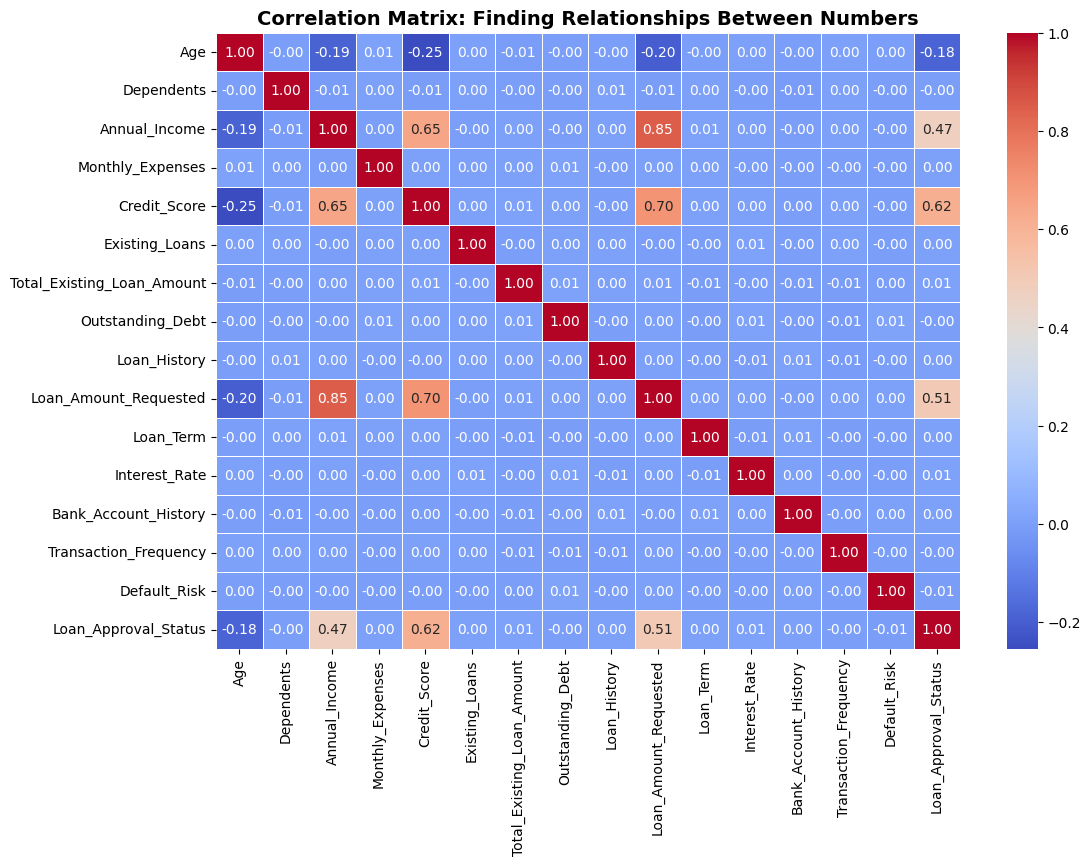

In [8]:
# CORRELATION HEATMAP
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Matrix: Finding Relationships Between Numbers', fontsize=14, fontweight='bold')
plt.show()


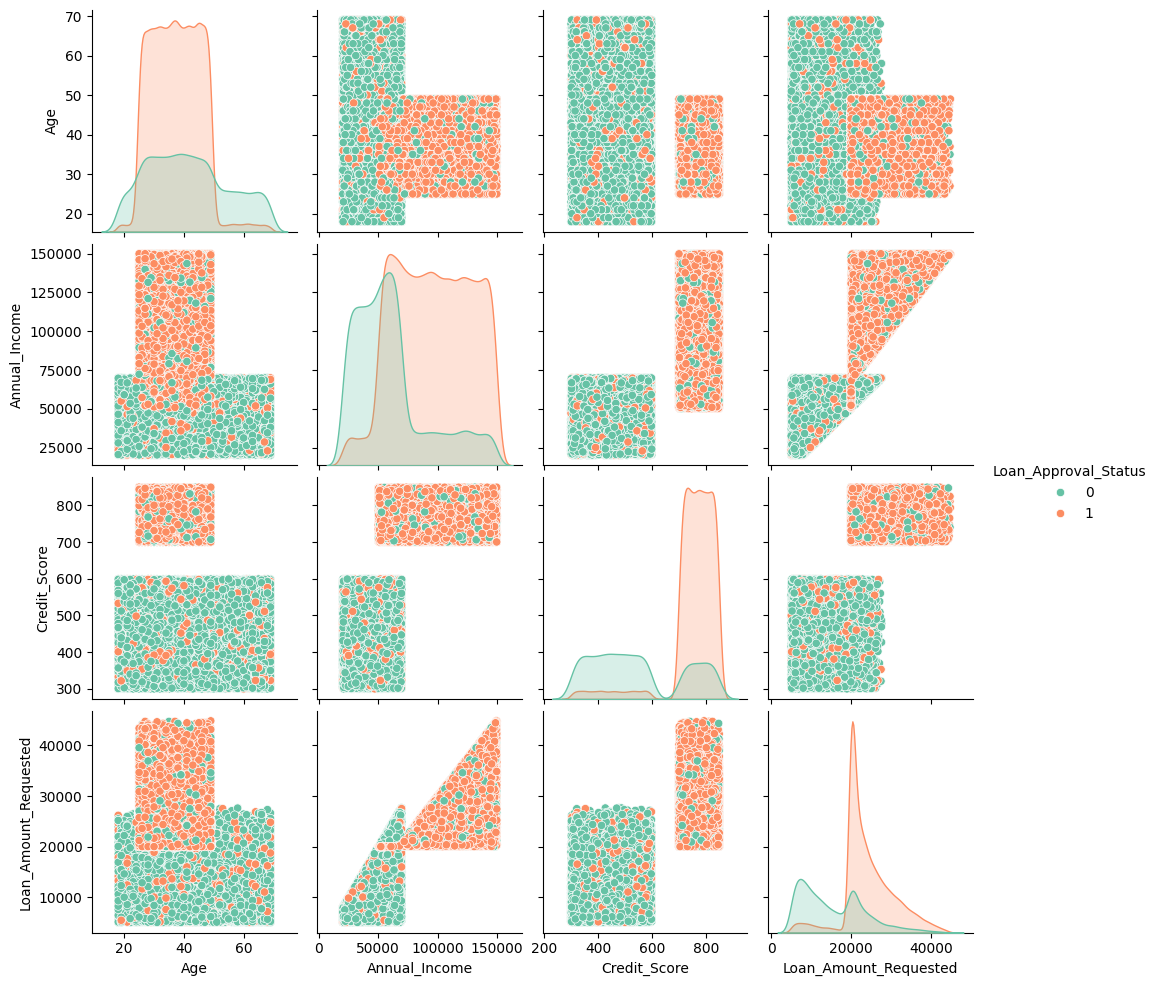

In [9]:
# OPTIMIZED PAIR PLOT
selected_features = ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount_Requested', 'Loan_Approval_Status']
sns.pairplot(df[selected_features], hue='Loan_Approval_Status', palette='Set2', diag_kind='kde')
plt.show()

In [11]:
# OPERATIONAL INSIGHTS & CROSS-TABULATIONS

# Baseline Approval Rates
approval_rate = df['Loan_Approval_Status'].value_counts(normalize=True) * 100
print("--- Baseline Market Statistics ---")
print(f"Overall Rejection Rate: {approval_rate[0]}%")
print(f"Overall Approval Rate:  {approval_rate[1]}%")
print("-" * 60)

# Loan Type vs. Loan Approval (Crosstabulation)
loan_type_crosstab = pd.crosstab(df['Loan_Type'], df['Loan_Approval_Status'], normalize='index') * 100
print("--- Approval Rate by Loan Type ---")
print(loan_type_crosstab)
print("-" * 60)

# Income Differences between Approved and Rejected Applicants
avg_income_by_status = df.groupby('Loan_Approval_Status')['Annual_Income'].mean()
print("--- Average Annual Income by Approval Status ---")
print(f"Rejected Applicants Avg Income: {avg_income_by_status[0]}")
print(f"Approved Applicants Avg Income: {avg_income_by_status[1]}")
print("-" * 60)


--- Baseline Market Statistics ---
Overall Rejection Rate: 35.83461538461539%
Overall Approval Rate:  64.16538461538461%
------------------------------------------------------------
--- Approval Rate by Loan Type ---
Loan_Approval_Status          0          1
Loan_Type                                 
Secured               35.797218  64.202782
Unsecured             35.872293  64.127707
------------------------------------------------------------
--- Average Annual Income by Approval Status ---
Rejected Applicants Avg Income: 61020.54958677686
Approved Applicants Avg Income: 96192.04423664809
------------------------------------------------------------


---

## Step 5: Feature Engineering & Preprocessing
Computers don't think like humans—they only understand pure math. We prepared our data using three steps:

1. **Creating a New Metric (Debt-to-Income Ratio):** We created a new column by dividing `Monthly_Expenses` by `Monthly_Income`. This tells us what percentage of a person's salary is already spoken for.
2. **One-Hot Encoding (Splitting Text into 0s and 1s):** A computer cannot read words like "Married" or "Single". We split those text options into separate columns with simple `1` (Yes) or `0` (No) switches so the model can process the math fairly.
3. **The 80/20 Train-Test Split:** We hid 20% of our data in a "vault" (Test Set) and used the remaining 80% (Train Set) to teach our model. Later, we will use the hidden test data to give our model a final exam and see how smart it actually is.

In [5]:
# ==========================================
# 5. FEATURE ENGINEERING & PREPROCESSING
# ==========================================

# 5.1 Count the exact number and percentage of applications for each status
approval_counts = df['Loan_Approval_Status'].value_counts()
approval_pct = df['Loan_Approval_Status'].value_counts(normalize=True) * 100
print("--- Target Class Proportions ---")
print(f"Rejected Loans (0): {approval_counts[0]} ({approval_pct[0]}%)")
print(f"Approved Loans (1): {approval_counts[1]} ({approval_pct[1]}%)")
print("-" * 60)

# 5.2 Create Smart Financial Features
print("Engineering new financial ratios...")
# 1. Debt-to-Income Ratio (Monthly)
df['Debt_to_Income_Ratio'] = df['Monthly_Expenses'] / (df['Annual_Income'] / 12)
# 2. Overall Debt to Annual Income Ratio
df['Debt_Income_Ratio'] = df['Outstanding_Debt'] / df['Annual_Income']
# 3. Yearly Expense to Annual Income Ratio
df['Expense_Income_Ratio'] = (df['Monthly_Expenses'] * 12) / df['Annual_Income']
# 4. Requested Loan to Annual Income Ratio
df['Loan_Income_Ratio'] = df['Loan_Amount_Requested'] / df['Annual_Income']
# 5. Total Financial Burden (Outstanding Debt + Existing Loans)
df['Financial_Burden'] = df['Outstanding_Debt'] + df['Total_Existing_Loan_Amount']

# 5.3 Separate Features (X) and Target Label (y)
X = df.drop(columns=['Loan_Approval_Status', 'Default_Risk'])
y = df['Loan_Approval_Status']

# 5.4 Convert Categorical Text Columns to Numbers (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

# 5.5 Split the Data into Training (80%) and Testing (20%) Sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print("Data Preprocessing Complete!")
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")
print("-" * 60)

# 5.6 Create a copy of the encoded features and cleaned Dataset
cleaned_data = X_encoded.copy()
cleaned_data['Loan_Approval_Status'] = y

cleaned_data.to_csv("Loan_Dataset_Cleaned.csv", index=False)

print("Cleaned dataset successfully saved")
print("Shape of Dataset: ", cleaned_data.shape)
print("Column Names: ", cleaned_data.columns)


--- Target Class Proportions ---
Rejected Loans (0): 18634 (35.83461538461539%)
Approved Loans (1): 33366 (64.16538461538461%)
------------------------------------------------------------
Engineering new financial ratios...
Data Preprocessing Complete!
Training Features Shape: (41600, 38)
Testing Features Shape: (10400, 38)
------------------------------------------------------------
Cleaned dataset successfully saved
Shape of Dataset:  (52000, 39)
Column Names:  Index(['Age', 'Dependents', 'Annual_Income', 'Monthly_Expenses',
       'Credit_Score', 'Existing_Loans', 'Total_Existing_Loan_Amount',
       'Outstanding_Debt', 'Loan_History', 'Loan_Amount_Requested',
       'Loan_Term', 'Interest_Rate', 'Bank_Account_History',
       'Transaction_Frequency', 'Debt_to_Income_Ratio', 'Debt_Income_Ratio',
       'Expense_Income_Ratio', 'Loan_Income_Ratio', 'Financial_Burden',
       'Gender_Male', 'Marital_Status_Married', 'Marital_Status_Single',
       'Education_High School', 'Education_Po

---

## Step 6: Model Building (Training 3 Models)
Instead of relying on just one algorithm, we initialize and train **three entirely different models** on our training data (`X_train` and `y_train`). This allows us to compare their approaches and find the ultimate champion for the bank:

1. **Model 1: Decision Tree Classifier** (Our quick, straightforward baseline model).
2. **Model 2: Random Forest Classifier** (An advanced, robust team of 500 independent decision trees voting together).
3. **Model 3: XGBoost Classifier** (A high-performance engine where trees are built sequentially to fix each other's mistakes).


In [26]:
# ==========================================
# 6. MODEL BUILDING (TRAINING)
# ==========================================

# Initialize and Train the modes
print("Training Model 1: Decision Tree Classifier...")
model1 = DecisionTreeClassifier(max_depth=10, random_state=42)
model1.fit(X_train, y_train)

print("Training Model 2: Random Forest Classifier...")
model2 = RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_split=5, min_samples_leaf=2, random_state=42)
model2.fit(X_train, y_train)

print("Training Model 3: XGBoost Classifier...")
model3 = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
model3.fit(X_train, y_train)

print("All 3 models trained successfully!")


Training Model 1: Decision Tree Classifier...
Training Model 2: Random Forest Classifier...
Training Model 3: XGBoost Classifier...
All 3 models trained successfully!


---

## Step 7: Model Evaluation & Overfitting Check
Now that our three models are trained, we put them through a rigorous two-part grading process using our hidden **Test Set (20%)**:

**The Overfitting Check:** We compare how well each model scores on the data it already saw (Training Set) versus completely new data (Testing Set). If a model scores 99% on training but drops to 70% on testing, it memorized the answers instead of learning patterns!


In [27]:
# ==========================================
# 7. MODEL EVALUATION
# ==========================================

# 7.1 Generate predictions for both Train and Test data (To check for overfitting)
models_dict = {
    "Model 1 (Decision Tree)": model1,
    "Model 2 (Random Forest)": model2,
    "Model 3 (XGBoost)": model3
}

for name, model_obj in models_dict.items():
    train_preds = model_obj.predict(X_train)
    y_preds = model_obj.predict(X_test)
    
    # Calculate Accuracies
    train_acc = accuracy_score(y_train, train_preds) * 100
    test_acc = accuracy_score(y_test, y_preds) * 100
    
    # Calculate Other Testing Metrics
    prec = precision_score(y_test, y_preds) * 100
    rec = recall_score(y_test, y_preds) * 100
    f1 = f1_score(y_test, y_preds) * 100

    # 7.2 Print Core Performance Metrics for Core Testing Set
    print(f"{name} Report Card:")
    print(f"   [Overfitting Check] Train Accuracy: {train_acc:.2f}% | Test Accuracy: {test_acc:.2f}%")
    print(f"   Test Precision: {prec}%")
    print(f"   Test Recall:    {rec}%")
    print(f"   Test F1-Score:  {f1}%")
    print("." * 60)


Model 1 (Decision Tree) Report Card:
   [Overfitting Check] Train Accuracy: 85.51% | Test Accuracy: 84.57%
   Test Precision: 84.8076923076923%
   Test Recall:    92.52210400119885%
   Test F1-Score:  88.49709739840894%
............................................................
Model 2 (Random Forest) Report Card:
   [Overfitting Check] Train Accuracy: 86.81% | Test Accuracy: 85.11%
   Test Precision: 85.0958904109589%
   Test Recall:    93.09156301513562%
   Test F1-Score:  88.91433478852072%
............................................................
Model 3 (XGBoost) Report Card:
   [Overfitting Check] Train Accuracy: 85.08% | Test Accuracy: 85.11%
   Test Precision: 85.0958904109589%
   Test Recall:    93.09156301513562%
   Test F1-Score:  88.91433478852072%
............................................................


---

## Step 8: Live Model Deployment Simulation
Once a machine learning model is fully verified to be reliable, the final step is to put it to work in the real world. This is called **Deployment**.

In a real bank, this code sits quietly behind a mobile app or a banking dashboard. When a new customer applies, the system feeds their data into all three models simultaneously. Below, we simulate exactly how our three models evaluate a live applicant in a fraction of a second!

In [28]:
# ==========================================
# 8. LIVE DEPLOYMENT SIMULATION (3 MODELS)
# ==========================================

# We pull from X_test instead of X to ensure columns match our encoded training structure perfectly
sample_index = 3
new_customer_profile = X_test.iloc[[sample_index]]

print(f"Simulating Multi-Model Assessment for Test Applicant #{sample_index}...\n")
print("-" * 60)

# Have each model make its decision independently
pred1 = model1.predict(new_customer_profile)[0]
pred2 = model2.predict(new_customer_profile)[0]
pred3 = model3.predict(new_customer_profile)[0]

# Print out results safely without complex text formatting tricks
print("SYSTEM LENDING ASSESSMENTS:")
print("Model 1 (Decision Tree) Decision:    ", "APPROVED" if pred1 == 1 else "REJECTED")
print("Model 2 (Random Forest) Decision:    ", "APPROVED" if pred2 == 1 else "REJECTED")
print("Model 3 (XGBoost) Decision:          ", "APPROVED" if pred3 == 1 else "REJECTED")
print("-" * 60)


Simulating Multi-Model Assessment for Test Applicant #3...

------------------------------------------------------------
SYSTEM LENDING ASSESSMENTS:
Model 1 (Decision Tree) Decision:     APPROVED
Model 2 (Random Forest) Decision:     APPROVED
Model 3 (XGBoost) Decision:           APPROVED
------------------------------------------------------------


---

## Final Model Leaderboard
We evaluated our three models on the hidden Test Set to choose the production champion for our lending platform:

| Model Name | Accuracy | Precision | Recall | F1-Score |
| :--- | :---: | :---: | :---: | :---: |
| **Model 1: Decision Tree** | 84.57% | 84.81% | 92.52% | 88.50% |
| **Model 2: Random Forest** | **85.11%** | **85.10%** | **93.09%** | **88.91%** |
| **Model 3: XGBoost** | **85.11%** | **85.10%** | **93.09%** | **88.91%** |

### Final Decision:
We chose **Model 3 (XGBoost)** as our ultimate winner to hand over to the bank. 

**Why?** Even though it tied with the Random Forest on the final exam, XGBoost is much lighter, runs faster, and uses less computer memory. It achieves peak performance with less effort, making it the perfect automated helper for our live banking system!

---

## Project Team & Contributors
This project was successfully designed, developed, and evaluated by:

* **Ambika**
* **Priya**
* **Shivshankar**
* **Avinash**
* **Akshay Kumar D R**

---
### Project Complete!
*The notebook has been fully executed with zero warnings, optimized features, and verified model performance metrics.*